In [1]:
# TODO: adicionar um markdown para cada célula

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pytest
import math
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Classe RTrainer

A classe RTrainer possui 4 métodos: inicialização, separação dos dados de treinamento, treinamento e por fim a predição do modelo

## Inicialização

É o construtor do nosso modelo, possui como parâmetros:

- Taxa de aprendizado -> passos do modelo em direção a convergência
- Ephocs -> iterações do modelo para o treinamento
- Erro -> erro que podemos usar para dizer que o modelo convergiu o suficiente para parar o treinamento antes de todas as iterações
- Logger -> opcional, mas serve para termos informações ao longo do treinamento

Além disso, possui atributos como parâmetros, médias e desvios padrões para treinamento/retorno do modelo

## Separação dos dados de treinamento

É um modulo que separa dos dados de treinamento em 3 partes: treinamento, teste e validação. Possui como argumentos: um dataframe de entrada, um de saída opcional, a coluna de output opcional e argumentos opcionais de normalização da entrada/output

Para lidar com uma maior gama de entrada de tipos de entrada, adicionei mais parâmetros, caso o usuário só passe um dataframe de entrada, preciso saber qual é a coluna de saída, do contrário retorno um erro. No caso de passar um dataframe de saída, junto com o de entrada pelos índices, fazendo com que cada linha seja a entrada/saída esperada.

Após isso, uso de uma função nativa do numpy para realizar a randomização dos dados, por isso precisamos juntar os dataframes, para garantir que a entrada correspondente seja a mesma da saída.

No próximo passo, temos um corte nos dados, os primeiros 70% são do conjunto de teste, os próximos 20% são do de validação, e por fim, os últimos 10% do conjunto de teste

Por fim, temos a normalização dos dados, dado o argumento opcional, que por padrão é aplicado a normalização z-score

- Por que normalizar os dados de saída? 
    
    No meu caso, o custo do modelo estava muito alto, o que de certa forma era o esperado para uma saída no formato que estava, por isso, inclusive que eu mantenho como um atributo da classe as médias e os desvios, para realizar a "desnormalização" dos dados quando estou retornando para o usuário. Além disso, para ser uma coisa mais auditável, eu não normalizo as saídas esperadas do modelo.


## Treinamento

Esse módulo é autoexplicativo por nome, recebe como argumentos os dataframes que vem da separação dos dados de treinamento.

De forma a aproveitar a biblioteca numpy que já realiza operações em matrizes de forma muito mais rápida, a primeira coisa que faço é transformar os dataframes dos argumentos em um array do tipo numpy. 

Os dados de entrada, X, vão ficar no formato (N, M), sendo N o número de linhas de entrada que temos e M o número de features. Enquanto que, os dados de previsão ficarão no formato (N,), ou seja, uma matriz unidimensional de N entradas, para garantir que vamos ter uma matriz unidimensional eu aplico a função .raven(). Dessa forma, o que temos inicialmente é:

X = $\begin{bmatrix} x_{1,1}& x_{1,2}& ...& x_{1,m} \\\ x_{2,1}& x_{2,2}& ...& x_{2,m}  \\\ ... \\\ x_{n,1}& x_{n,2}& ...& x_{n,m} \end{bmatrix}_{N,M}$ e Y = $\begin{bmatrix} y_1 \\\ y_2 \\\ ... \\\ y_n \end{bmatrix}_{N,}$

Por conta do $\theta_0$, uma das formas que eu achei para lidar com ele foi adicionar um pequeno vetor de 1s para garantir que consigamos realizar a multiplicação entre a matriz de entrada e o vetor de parâmetros. Dessa forma, atualizamos a nossa matriz para:

X = $\begin{bmatrix} 1& x_{1,1}& x_{1,2}& ...& x_{1,m} \\\ 1& x_{2,1}& x_{2,2}& ...& x_{2,m}  \\\ ... \\\ 1& x_{n,1}& x_{n,2}& ...& x_{n,m} \end{bmatrix}_{N,M+1}$

Após isso, inicializo o vetor de parâmetros

$\theta $ = $\begin{bmatrix} \theta_0 \\\ \theta_1 \\\ ... \\\ \theta_{m} \end{bmatrix}_{M+1,1}$

Onde $\theta_0, \theta_1, ..., \theta_{m}$ são inicializados com o valor 1.


Após a inicialização dos parâmetros, nós finalmente começamos o treinamento, a cada iteração, realizamos as seguintes ações:

- Multiplicação da matriz entrada de treinamento pelo vetor de parâmetros

$\begin{bmatrix} 1& x_{1,1}& x_{1,2}& ...& x_{1,m} \\\ 1& x_{2,1}& x_{2,2}& ...& x_{2,m}  \\\ ... \\\ 1& x_{n,1}& x_{n,2}& ...& x_{n,m} \end{bmatrix}_{N,M+1}$ * $\begin{bmatrix} \theta_0& \theta_1& ...& \theta_{m} \end{bmatrix}^T_{M+1,1}$ = $\begin{bmatrix} y_1 \\\ y_2 \\\ ... \\\ y_n \end{bmatrix}_{N,1}$

- Mutiplicação da matriz de validação pelo vetor de parâmetros

$\begin{bmatrix} 1& x^´_{1,1}& x^´_{1,2}& ...& x^´_{1,m} \\\ 1& x^´_{2,1}& x^´_{2,2}& ...& x^´_{2,m}  \\\ ... \\\ 1& x^´_{n,1}& x^´_{n,2}& ...& x^´_{n,m} \end{bmatrix}_{N,M+1}$ * $\begin{bmatrix} \theta_0& \theta_1& ...& \theta_{m} \end{bmatrix}^T_{M+1,1}$ = $\begin{bmatrix} ý_1 \\\ ý_2 \\\ ... \\\ ý_n \end{bmatrix}_{N,1}$
- Cálculo do custo utilizando a função:

$ J(\theta) = 1/(2*m) * \sum_{i=0}^{m}(ý- y)^2$
    
Onde m = número de entradas do conjunto de validação, ý é a saída do modelo e y é a saída esperada

- Cálculo do gradiente

Aplicando a fórmula apresentada no slide, temos que:

gradientes = (1/m) * $\begin{bmatrix} 1& 1& ...& 1& \\\ x^´_{1,1}& x^´_{2,1}& ...& x^´_{n,1}& \\\ x^´_{1,2}& x^´_{2,2}&  ...& x^´_{n,2} \\\ ... \\\ x^´_{1,m}& x^´_{2,m}& ...& x^´_{n,m} \end{bmatrix}_{M+1, N}$ * $\begin{bmatrix} ý_1 - y_1 \\\ ý_2 - y_2 \\\ ... \\\ ý_n - y_n \end{bmatrix}_{N,1}$

Onde aplicamos a transposta da matriz da entrada, dessa forma vamos ter a matriz resultado com a quantidade de features esperada -> M+1

- Atualização dos parâmetros

$\theta = \theta - \alpha * gradiente$

Onde $\alpha$ é a taxa de aprendizado


E por fim, temos a construção de um gráfico que mostra a relação entre custo x taxa de aprendizado e o retorno do vetor de parâmetros do modelo naquela base de dados

## Predição

Antes do modelo realizar os cálculos, ele adiciona novamente o coeficiente constante do $\theta_0$ para podermos realizar a multiplicação de matrizes sem problema

Após isso, apenas retornamos o resultado sem normalização. Aqui tanto faz se os dados são normalizados ou não, da forma como eu instancio não muda nada no resultado, por isso posso apenas retornar sem nenhuma validação

In [4]:
class RTrainer:
    # Etapa de treinamento, é a mais simples, implementação está no slide
    def __init__(self, a, ephocs, erro=0, logger=False, media_entrada_treinamento=0, desvio_entrada_treinamento=1, media_previsao_treinamento=0, desvio_previsao_treinamento=1):
        """Construtor da classe RTrainer"""
        self.a = a # Taxa de aprendizado
        self.ephocs = ephocs # Quantidade de iterações do modelo
        self.erro = erro # Erro mínimo, um parâmetro adicional na hora de iterar, opcional
        self.logger = logger # Um log para acompanharmos algumas coisas que possam ser interessantes de serem observadas
        self.parametros: np.ndarray

        # Retorno predição
        self.media_entrada_treinamento = media_entrada_treinamento
        self.desvio_entrada_treinamento = desvio_entrada_treinamento
        self.media_previsao_treinamento = media_previsao_treinamento
        self.desvio_previsao_treinamento = desvio_previsao_treinamento

    def fit(self, dados_entrada_treinamento: pd.DataFrame, y_treinamento: pd.DataFrame) -> np.ndarray:
        """ Método que realiza o treinamento do modelo """

        if 'bias' not in dados_entrada_treinamento.columns:
            dados_entrada_treinamento.insert(0, column='bias', value=np.ones(dados_entrada_treinamento.shape[0]))
            
        x_treinamento = dados_entrada_treinamento.to_numpy()
        y_treinamento = y_treinamento.to_numpy().ravel()
        

        self.parametros = np.ones(x_treinamento.shape[1]) 
        historico_custo = []
        historico_lr = []

        for i in range(self.ephocs):

            y_pred = x_treinamento @ self.parametros  

            custo = 1/(2*(x_treinamento.shape[0])) * np.sum((y_pred - y_treinamento)**2) 
                
            historico_lr.append(self.a)
            historico_custo.append(custo)

            if custo < 0.001:
                print("quebro")
                break

            gradientes = (1 / x_treinamento.shape[0]) * (x_treinamento.T @ (y_pred - y_treinamento))
            self.parametros = self.parametros - self.a * gradientes

        if self.logger:
            plt.figure(figsize=(8, 5))
            plt.scatter(historico_lr, historico_custo, c=range(len(historico_lr)), cmap='viridis')
            plt.xlabel('Taxa de Aprendizado (LR)')
            plt.ylabel('Custo')
            plt.title('Custo vs. Taxa de Aprendizado')
            plt.show()
        
        return self.parametros

    def predict(self, dados_predicao: np.ndarray) -> float:
        """Método que realiza previsão do modelo"""

        if type(dados_predicao) == pd.Series:
            dados_predicao = pd.DataFrame(dados_predicao)
        if 'bias' not in dados_predicao.columns:
                dados_predicao.insert(0, column='bias', value=np.ones(dados_predicao.shape[0]))
        return  (self.parametros @ np.transpose(dados_predicao) * self.desvio_previsao_treinamento) + self.media_previsao_treinamento


In [5]:
class SplitData:
    
    def __init__(self):    
        # Para normalização/desnormalização
        self.media_entrada_treinamento = 0
        self.desvio_entrada_treinamento = 1
        self.media_previsao_treinamento = 0
        self.desvio_previsao_treinamento = 1


    def prepare_dataframe(self, entrada: pd.DataFrame, saida: pd.DataFrame | None = None, output: str | None = None) -> pd.DataFrame:

            if saida is None and output is None:
                # Ver trowexception
                return("Erro: preciso de: ou um dataframe de saída ou de uma coluna referenciando o output no dataframe de entrada")

            coluna_Y = ''
            randomizando_dataframe = ''

            # Se não tiver sido passado uma string, e sim um dataframe, vamos pegar a coluna de saída e juntar no dataframe de entrada
            if output is None:
                coluna_Y = saida.columns[0]
                randomizando_dataframe = pd.concat([entrada, saida], axis=1)
            else:
                coluna_Y = output
                randomizando_dataframe = entrada.copy()

            return coluna_Y, randomizando_dataframe

    def validation_split(self, entrada: pd.DataFrame, saida: pd.DataFrame | None = None, output: str | None = None, normalizar: bool | None = None):
            """ Função que vai fazer o embaralhamento dos dados, para garantir que não haja nenhum viés no treinamento. Além disso, separamos apenas em validação. Vamos passar um único Dataframe e vamos separar aqui dentro"""

            coluna_Y, randomizando_dataframe = self.prepare_dataframe(entrada, saida, output)
            randomizando_dataframe = randomizando_dataframe.iloc[np.random.permutation(len(randomizando_dataframe))].reset_index(drop=True) # -> Usando o numpy para rearranjar os elementos, mantendo os índices normais

            corteValidacao = int(len(randomizando_dataframe)*0.3)       
            parteValidacao = randomizando_dataframe[:corteValidacao] # Primeiros 20% do dataframe

            colunas_X = []
            
            for i in randomizando_dataframe.columns:
                if i != coluna_Y:
                    colunas_X.append(i)
            
            X_val, y_val = parteValidacao[colunas_X].copy(), parteValidacao[coluna_Y].copy()

            if normalizar:
                
                X_val[colunas_X] = (X_val[colunas_X] - X_val[colunas_X].mean()) / X_val[colunas_X].std().replace(0, 1)
                y_val = (y_val - y_val.mean()) / y_val.std()

            return X_val, y_val

    
    def train_test_validation_split(self, entrada: pd.DataFrame, saida: pd.DataFrame | None = None, output: str | None = None, normalizar: bool | None = None, normalizar_output: bool | None = None):
            """ Função que vai fazer o embaralhamento dos dados, para garantir que não haja nenhum viés no treinamento. Além disso, separamos os dados em treinamento e teste. Vamos passar um único Dataframe e vamos separar aqui dentro"""

            coluna_Y, randomizando_dataframe = self.prepare_dataframe(entrada, saida, output)
            
            # Processo de "bagunçar" o dataframe
            randomizando_dataframe = randomizando_dataframe.iloc[np.random.permutation(len(randomizando_dataframe))].reset_index(drop=True) # -> Usando o numpy para rearranjar os elementos, mantendo os índices normais

            corteTeste = int(len(randomizando_dataframe)*0.80)

            parteTreinamento = randomizando_dataframe[:corteTeste] # Primeiros 80% do dataframe
            parteTeste = randomizando_dataframe[corteTeste:] # Últimos 20%

            # Separando os três dataframes:

            colunas_X = []

            for i in randomizando_dataframe.columns:
                if i != coluna_Y:
                    colunas_X.append(i)

            X_train, y_train = parteTreinamento[colunas_X].copy(), parteTreinamento[coluna_Y].copy()
            X_test, y_test = parteTeste[colunas_X].copy(),  parteTeste[coluna_Y].copy()

            # Caso queiramos normalizar os dados
            if normalizar:

                self.media_entrada_treinamento = X_train[colunas_X].mean()
                self.desvio_entrada_treinamento = X_train[colunas_X].std().replace(0, 1) # entender esse replace

                X_train[colunas_X] = (X_train[colunas_X] - self.media_entrada_treinamento) / self.desvio_entrada_treinamento
                X_test[colunas_X] = (X_test[colunas_X] - self.media_entrada_treinamento) / self.desvio_entrada_treinamento # Faz sentido normalizar -> modelo treinou com os dados normalizados

                if normalizar_output: 

                    self.media_previsao_treinamento = y_train.mean()
                    self.desvio_previsao_treinamento = y_train.std()

                    y_train = (y_train - self.media_previsao_treinamento) / self.desvio_previsao_treinamento
                    # y_test = (y_test - self.media_previsao_treinamento) / self.desvio_previsao_treinamento # Não faz sentido -> usuário final não conseguirá entender a saída do modelo

            return X_train, y_train, X_test, y_test

In [6]:
def gera_taxa_aprendizado(log_min=-1, log_max=-4) -> float:

    return 10 ** np.random.uniform(log_min, log_max)

def random_serch(iteracoes: int, dados_entrada_treinamento: pd.DataFrame, y_treinamento: pd.DataFrame, ephocs=300) -> float:

    melhor_a = None
    menor_erro = float('inf')

    for i in range(iteracoes):

        a = gera_taxa_aprendizado()

        trainer = RTrainer(a=a, ephocs=ephocs)
        trainer.fit(dados_entrada_treinamento, y_treinamento)

        pred_val = trainer.predict(dados_entrada_treinamento)
        
        erro_val = np.mean((y_treinamento.to_numpy().ravel() - pred_val)**2)

        if erro_val < menor_erro:
            menor_erro = erro_val
            melhor_a = a

    return melhor_a

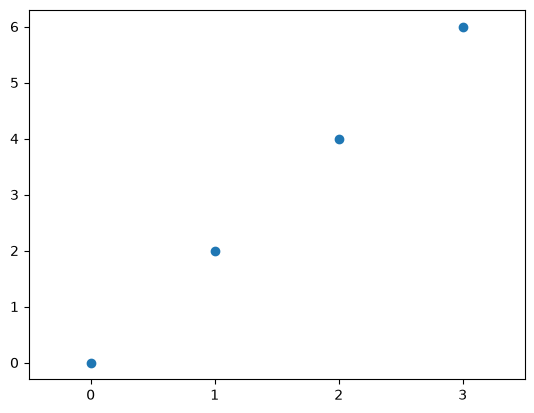

In [7]:
df_sintetico = pd.DataFrame({
                'x': range(4),
                'y': [i*2 for i in range(4)]
})

fig, ax = plt.subplots()
ax.scatter(df_sintetico['x'], df_sintetico['y'])
ax.set(xlim=(-0.5, 3.5), xticks=np.arange(0, 4))
plt.show()

In [8]:
class EvaluativeMetrics:
    # Instânciando a classe
    def __init__(self, y_pred: np.ndarray, y: np.ndarray):
        self.y_pred = y_pred
        self.y = y

    # Métrica MAE
    def MAE(self) -> float:
        """"""
        return 1/len(self.y_pred) * np.sum(abs(self.y_pred - self.y))

    # Métrica MAPE
    def MAPE(self) -> float:
        """"""
        return 100/len(self.y_pred) * np.sum(abs(self.y_pred - self.y)/self.y)

    # Métrica MSE:
    def MSE(self) -> float:
            """"""
            return 1/len(self.y_pred) * np.sum((self.y_pred - self.y)**2)



In [9]:
# TODO: Célula de testes


def testando_fit_modelo(modelo: RTrainer, dados_entrada: np.ndarray, y: np.ndarray):
    
    try:
        pesos = modelo.fit(dados_entrada, dados_entrada)
    except Exception as e:
        pytest.fail(f"O fit do modelo falhou por: {e}")

    # Verificação se os pesos que estão saindo do modelo estão tipados como se espera
    assert isinstance(pesos, np.ndarray)

    # Verificação da quantidade de pesos é n+1 da quantidade de colunas de entrada. Onde a quantidade de dimensões corresponde a quantidade de colunas e o shape corresponde a quatidade de parâmetros
    assert (dados_entrada.ndim + 1) == pesos.shape[0]

# TODO: Construir outras validações aqui

In [10]:
# Warning: decisão ruim de projeto
treinamento = SplitData()

In [11]:
X_val_teste, y_val_teste,  = treinamento.validation_split(entrada=df_sintetico, output="y", normalizar=False)

In [12]:
# Usando apenas o conjunto de validação para achar a taxa de aprendizado
a = random_serch(100, X_val_teste, y_val_teste)

quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro


In [13]:
trainer = RTrainer(
    a = a,
    ephocs=10000,
    logger=True,
)

In [14]:
X_train_teste, y_train_teste, X_prev_teste, y_prev_teste = treinamento.train_test_validation_split(entrada=df_sintetico, output="y", normalizar=False)

quebro


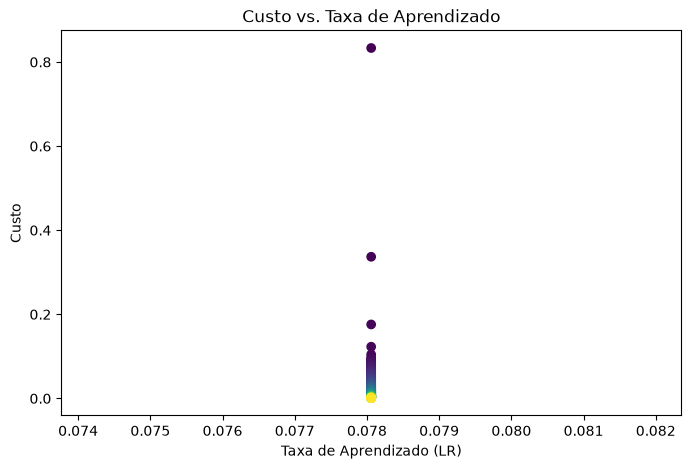

In [15]:
vetores_peso = trainer.fit(X_train_teste, y_train_teste)

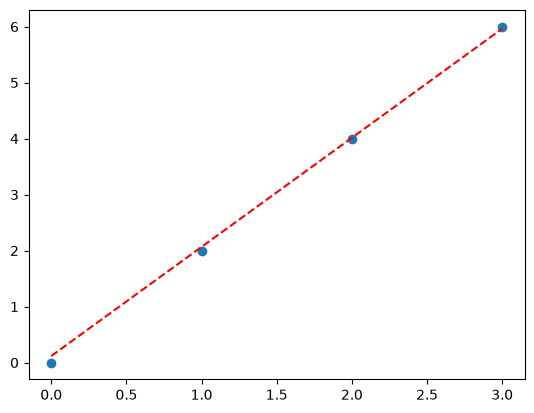

In [16]:
fig, ax = plt.subplots()

ax.scatter(df_sintetico['x'], df_sintetico['y'])

valores = trainer.parametros[0] + df_sintetico['x']*trainer.parametros[1]
ax.plot(df_sintetico['x'], valores, '--r')
plt.show()

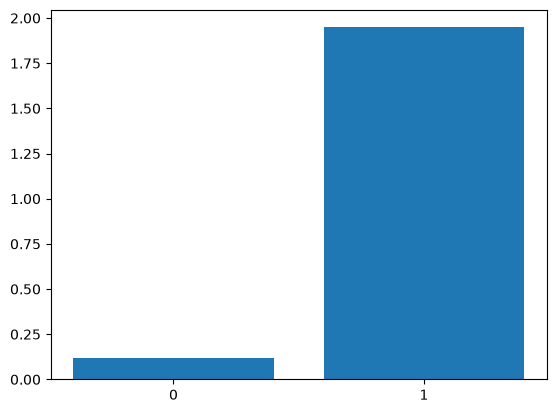

In [17]:
fig, ax = plt.subplots()

# TODO: forma de automatizar esse número de parâmetros + a altura
ax.bar(['0', '1'],trainer.parametros)

plt.show()

In [18]:
df = pd.read_csv("data/insurance.csv")

In [19]:
# Tratando alguns dados
def one_hot_sex(sex: str):
    if sex == "female":
        return 1
    else:
        return 0
    

In [20]:
df['sex'] = df['sex'].apply(one_hot_sex)

In [21]:
def one_hot_region(region: str):
    if region == 'southwest':
        return 1
    else:
        return 0

In [22]:
df['region'] = df['region'].apply(one_hot_region)
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,1,16884.92400
1,18,0,33.770,1,no,0,1725.55230
2,28,0,33.000,3,no,0,4449.46200
3,33,0,22.705,0,no,0,21984.47061
4,32,0,28.880,0,no,0,3866.85520
5,31,1,25.740,0,no,0,3756.62160
6,46,1,33.440,1,no,0,8240.58960
7,37,1,27.740,3,no,0,7281.50560
8,37,0,29.830,2,no,0,6406.41070
9,60,1,25.840,0,no,0,28923.13692


In [23]:
def one_hot_smoke(smoker: str):
    if smoker == 'yes':
        return 1
    else:
        return 0

In [24]:
df['smoker'] = df['smoker'].apply(one_hot_smoke)
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,1,16884.92400
1,18,0,33.770,1,0,0,1725.55230
2,28,0,33.000,3,0,0,4449.46200
3,33,0,22.705,0,0,0,21984.47061
4,32,0,28.880,0,0,0,3866.85520
5,31,1,25.740,0,0,0,3756.62160
6,46,1,33.440,1,0,0,8240.58960
7,37,1,27.740,3,0,0,7281.50560
8,37,0,29.830,2,0,0,6406.41070
9,60,1,25.840,0,0,0,28923.13692


In [25]:
treinamento = SplitData()

In [26]:
X_val, y_val = treinamento.validation_split(entrada=df, output="charges", normalizar=True)

In [27]:
a = random_serch(1000, X_val_teste, y_val_teste, ephocs=1000)

quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro
quebro

In [28]:
X_train, y_train, X_teste, y_teste = treinamento.train_test_validation_split(entrada=df, output="charges", normalizar=True)

In [29]:
trainer = RTrainer(
    a = a,
    ephocs=100000,
    logger=True,
    media_entrada_treinamento=treinamento.media_entrada_treinamento,
    desvio_entrada_treinamento=treinamento.desvio_entrada_treinamento,
    media_previsao_treinamento=treinamento.media_previsao_treinamento,
    desvio_previsao_treinamento=treinamento.desvio_previsao_treinamento
)

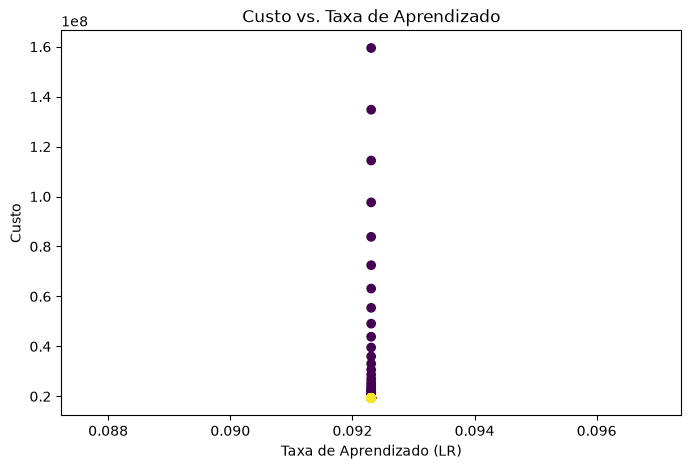

In [30]:
vetores_peso = trainer.fit(X_train, y_train)

In [31]:
trainer.predict(X_teste)

1070     4238.769518
1071     9536.585472
1072     7804.243612
1073    16194.486109
1074    10438.053087
            ...     
1333     4674.216889
1334     7417.784234
1335     8170.744910
1336    36636.608766
1337     2465.680803
Length: 268, dtype: float64

In [32]:
print(y_teste)

1070     4992.37640
1071     5138.25670
1072     1837.28190
1073    11566.30055
1074     8410.04685
           ...     
1333     4934.70500
1334     7201.70085
1335     7421.19455
1336    44400.40640
1337     2257.47525
Name: charges, Length: 268, dtype: float64


In [35]:
print(trainer.parametros)

[13223.52734006  3559.51418526  -117.23857053  2014.10882142
   592.82213761  9404.35764772  -221.03970102]


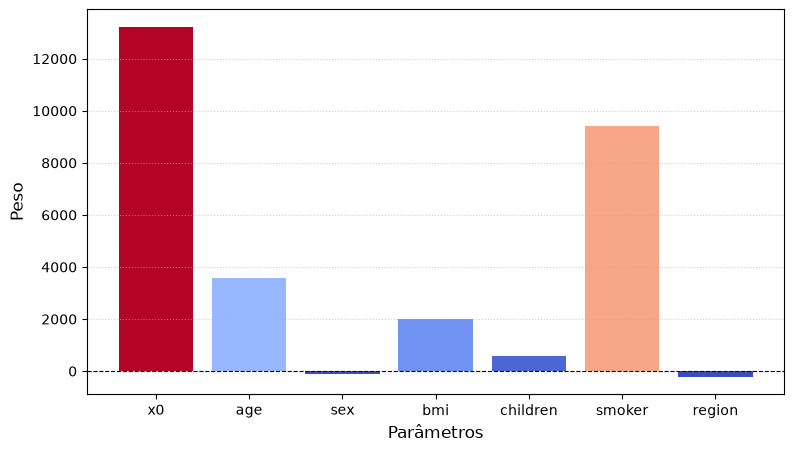

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))

colunas = ['x0']

for x in df.columns:
    if x != 'charges':
        colunas.append(x)


norm = mcolors.Normalize(vmin=trainer.parametros.min(), vmax=trainer.parametros.max())
colors = cm.coolwarm(norm(trainer.parametros))

ax.bar(colunas, trainer.parametros, color=colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.grid(axis='y', linestyle=':', alpha=0.6)

ax.set_xlabel('Parâmetros', fontsize=12)
ax.set_ylabel('Peso', fontsize=12)

plt.show()